In [1]:
# Core
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Models
import timm

# Metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import cohen_kappa_score

# Visualization
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


c:\Users\Adarsh Sharma\OneDrive\Desktop\major projetc\X-EyeNet\eye_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
CSV_PATH = r"C:\Users\Adarsh Sharma\OneDrive\Desktop\major projetc\X-EyeNet\dataset2\train.csv"
PREP_PATH = r"C:\Users\Adarsh Sharma\OneDrive\Desktop\major projetc\X-EyeNet\dataset2_preprocessed"

df = pd.read_csv(CSV_PATH)

df["image_path"] = df["id_code"].apply(
    lambda x: os.path.join(PREP_PATH, "train", f"{x}.jpg")
)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["diagnosis"], random_state=42
)


train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))


Train: 2929 Val: 733


In [3]:
train_df["image_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(PREP_PATH, "train", f"{x}.jpg")
)

val_df["image_path"] = val_df["id_code"].apply(
    lambda x: os.path.join(PREP_PATH, "valid", f"{x}.jpg")
)

print(train_df.iloc[0]["image_path"], os.path.exists(train_df.iloc[0]["image_path"]))
print(val_df.iloc[0]["image_path"], os.path.exists(val_df.iloc[0]["image_path"]))


C:\Users\Adarsh Sharma\OneDrive\Desktop\major projetc\X-EyeNet\dataset2_preprocessed\train\b2b79b37d314.jpg True
C:\Users\Adarsh Sharma\OneDrive\Desktop\major projetc\X-EyeNet\dataset2_preprocessed\valid\6fe67fd7f5d1.jpg True


In [4]:
class APTOSDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        img = cv2.imread(img_path)

        # SAFETY CHECK
        if img is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))

        label = torch.tensor(row["diagnosis"], dtype=torch.float32)

        return torch.tensor(img), label


In [5]:
train_loader = DataLoader(
    APTOSDataset(train_df),
    batch_size=16,
    shuffle=True,
    num_workers=0   # IMPORTANT on Windows
)

val_loader = DataLoader(
    APTOSDataset(val_df),
    batch_size=16,
    shuffle=False,
    num_workers=0
)



In [6]:
class EfficientNetB3Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=False,
            num_classes=0
        )
        self.fc = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        x = self.backbone(x)
        return self.fc(x)


In [7]:
model = EfficientNetB3Regression().to(device)
model.load_state_dict(
    torch.load("efficientnet_b3_final.pth", map_location=device)
)

print("Model with QWK ≈ 0.88 loaded")


C:\Users\Adarsh Sharma\AppData\Local\Temp\ipykernel_3440\1466518119.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("efficientnet_b3_final.pth", map_location=

Model with QWK ≈ 0.88 loaded


In [8]:
# Freeze entire backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze only top layers
for name, param in model.backbone.named_parameters():
    if "blocks.4" in name or "blocks.5" in name or "conv_head" in name:
        param.requires_grad = True

# Always train regression head
for param in model.fc.parameters():
    param.requires_grad = True


In [9]:
labels = train_df["diagnosis"].values
weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

def weighted_smooth_l1_loss(pred, target):
    pred = pred.squeeze(1)
    loss = F.smooth_l1_loss(pred, target, reduction="none")
    w = class_weights[target.long()]
    return (loss * w).mean()


In [10]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,      # 🔥 LOWER LR
    weight_decay=1e-4
)


In [11]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = weighted_smooth_l1_loss(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs).squeeze(1)

            preds.extend(outputs.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    preds_cls = np.clip(np.round(preds), 0, 4).astype(int)
    kappa = cohen_kappa_score(targets, preds_cls, weights="quadratic")
    return kappa


In [12]:
FINE_TUNE_EPOCHS = 5
best_kappa = 0.88

for epoch in range(FINE_TUNE_EPOCHS):
    print(f"\nFine-tuning Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader)
    val_kappa = validate_one_epoch(model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Kappa: {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), "efficientnet_b3_finetuned.pth")
        print(f"🔥 Improved model saved (QWK={best_kappa:.4f})")



Fine-tuning Epoch 1/5
Train Loss: 0.0366
Val Kappa: 0.8687

Fine-tuning Epoch 2/5
Train Loss: 0.0193
Val Kappa: 0.8826
🔥 Improved model saved (QWK=0.8826)

Fine-tuning Epoch 3/5
Train Loss: 0.0168
Val Kappa: 0.8857
🔥 Improved model saved (QWK=0.8857)

Fine-tuning Epoch 4/5
Train Loss: 0.0167
Val Kappa: 0.8789

Fine-tuning Epoch 5/5
Train Loss: 0.0162
Val Kappa: 0.8830


In [13]:
class EfficientNetB3_CORAL(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b3",
            pretrained=False,
            num_classes=0   # outputs feature vector
        )
        self.fc = nn.Linear(self.backbone.num_features, num_classes - 1)

    def forward(self, x):
        features = self.backbone(x)   # 🔥 THIS WAS MISSING
        logits = self.fc(features)
        return logits


In [14]:
coral_model = EfficientNetB3_CORAL(num_classes=5).to(device)

# load backbone weights only
state = torch.load("efficientnet_b3_final.pth", map_location=device)

filtered_state = {
    k.replace("backbone.", ""): v
    for k, v in state.items()
    if "backbone." in k
}

coral_model.backbone.load_state_dict(filtered_state, strict=False)

print("Backbone weights transferred to CORAL model")


Backbone weights transferred to CORAL model


C:\Users\Adarsh Sharma\AppData\Local\Temp\ipykernel_3440\1404952413.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("efficientnet_b3_final.pth", map_l

In [15]:
for param in coral_model.backbone.parameters():
    param.requires_grad = False

for param in coral_model.fc.parameters():
    param.requires_grad = True


In [16]:
imgs, labels = next(iter(train_loader))
imgs = imgs.to(device)

with torch.no_grad():
    out = coral_model(imgs)

print("Output shape:", out.shape)


Output shape: torch.Size([16, 4])


In [17]:
def coral_encode(labels, num_classes=5):
    """
    Convert scalar labels → CORAL binary vectors
    Example: label=2 → [1,1,0,0]
    """
    batch_size = labels.size(0)
    coral_labels = torch.zeros(batch_size, num_classes - 1).to(labels.device)

    for i in range(num_classes - 1):
        coral_labels[:, i] = (labels > i).float()

    return coral_labels


In [18]:
def coral_loss(logits, labels):
    """
    logits: (B, K-1)
    labels: (B,)
    """
    coral_targets = coral_encode(labels)
    return F.binary_cross_entropy_with_logits(logits, coral_targets)


In [19]:
def coral_predict(logits):
    probs = torch.sigmoid(logits)
    return torch.sum(probs > 0.5, dim=1)


In [20]:
optimizer = torch.optim.AdamW(
    coral_model.fc.parameters(),
    lr=3e-4,      # higher LR OK (only head)
    weight_decay=1e-4
)


In [21]:
def train_coral_epoch(model, loader):
    model.train()
    total_loss = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = coral_loss(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_coral(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            pred = coral_predict(logits)

            preds.extend(pred.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    return cohen_kappa_score(targets, preds, weights="quadratic")


In [22]:
EPOCHS = 10
best_kappa = 0

for epoch in range(EPOCHS):
    print(f"\nCORAL Epoch {epoch+1}/{EPOCHS}")

    train_loss = train_coral_epoch(coral_model, train_loader)
    val_kappa = validate_coral(coral_model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val QWK: {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(coral_model.state_dict(), "efficientnet_b3_CORAL.pth")
        print(f"🔥 CORAL model saved (QWK={best_kappa:.4f})")



CORAL Epoch 1/10
Train Loss: 0.3699
Val QWK: 0.8587
🔥 CORAL model saved (QWK=0.8587)

CORAL Epoch 2/10
Train Loss: 0.1817
Val QWK: 0.8656
🔥 CORAL model saved (QWK=0.8656)

CORAL Epoch 3/10
Train Loss: 0.1358
Val QWK: 0.8703
🔥 CORAL model saved (QWK=0.8703)

CORAL Epoch 4/10
Train Loss: 0.1085
Val QWK: 0.8773
🔥 CORAL model saved (QWK=0.8773)

CORAL Epoch 5/10
Train Loss: 0.0902
Val QWK: 0.8753

CORAL Epoch 6/10
Train Loss: 0.0811
Val QWK: 0.8771

CORAL Epoch 7/10
Train Loss: 0.0725
Val QWK: 0.8791
🔥 CORAL model saved (QWK=0.8791)

CORAL Epoch 8/10
Train Loss: 0.0711
Val QWK: 0.8729

CORAL Epoch 9/10
Train Loss: 0.0627
Val QWK: 0.8812
🔥 CORAL model saved (QWK=0.8812)

CORAL Epoch 10/10
Train Loss: 0.0580
Val QWK: 0.8747


In [23]:
def collect_coral_outputs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy()

            all_probs.append(probs)
            all_labels.append(labels.numpy())

    return np.vstack(all_probs), np.hstack(all_labels)


In [24]:
def coral_predict_with_thresholds(probs, thresholds):
    preds = []
    for p in probs:
        cls = sum(p[i] > thresholds[i] for i in range(len(thresholds)))
        preds.append(cls)
    return np.array(preds)


In [25]:
from itertools import product
from sklearn.metrics import cohen_kappa_score

def optimize_thresholds(probs, labels):
    best_kappa = -1
    best_t = None

    # reasonable search space
    values = np.arange(0.3, 0.7, 0.05)

    for t in product(values, repeat=4):
        preds = coral_predict_with_thresholds(probs, t)
        kappa = cohen_kappa_score(labels, preds, weights="quadratic")

        if kappa > best_kappa:
            best_kappa = kappa
            best_t = t

    return best_kappa, best_t


In [26]:
FINE_TUNE_EPOCHS = 5
best_kappa = 0.88

for epoch in range(FINE_TUNE_EPOCHS):
    print(f"\nFine-tuning Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader)
    val_kappa = validate_one_epoch(model, val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Kappa: {val_kappa:.4f}")

    if val_kappa > best_kappa:
        best_kappa = val_kappa
        torch.save(model.state_dict(), "efficientnet_b3_finetuned.pth")
        print(f"🔥 Improved model saved (QWK={best_kappa:.4f})")



Fine-tuning Epoch 1/5
Train Loss: 0.0146
Val Kappa: 0.8800
🔥 Improved model saved (QWK=0.8800)

Fine-tuning Epoch 2/5
Train Loss: 0.0150
Val Kappa: 0.8778

Fine-tuning Epoch 3/5
Train Loss: 0.0133
Val Kappa: 0.8811
🔥 Improved model saved (QWK=0.8811)

Fine-tuning Epoch 4/5
Train Loss: 0.0147
Val Kappa: 0.8803

Fine-tuning Epoch 5/5
Train Loss: 0.0154
Val Kappa: 0.8807


In [27]:
probs, labels = collect_coral_outputs(coral_model, val_loader)
best_kappa, best_thresholds = optimize_thresholds(probs, labels)

print("Best CORAL QWK:", best_kappa)
print("Best thresholds:", best_thresholds)


Best CORAL QWK: 0.8853412186471294
Best thresholds: (0.3, 0.3, 0.35, 0.6499999999999999)


In [28]:
# Save final CORAL model
torch.save(coral_model.state_dict(), "FINAL_EfficientNetB3_CORAL.pth")

# Save optimized thresholds
final_thresholds = [0.3, 0.4, 0.35, 0.55]

np.save("FINAL_CORAL_thresholds.npy", np.array(final_thresholds))

print("✅ Final model and thresholds saved")


✅ Final model and thresholds saved


In [29]:
def load_final_model(device):
    model = EfficientNetB3_CORAL(num_classes=5).to(device)
    model.load_state_dict(torch.load("FINAL_EfficientNetB3_CORAL.pth", map_location=device))
    model.eval()

    thresholds = np.load("FINAL_CORAL_thresholds.npy")
    return model, thresholds


In [30]:
def coral_predict_single(logits, thresholds):
    probs = torch.sigmoid(logits).cpu().numpy()[0]
    pred_class = sum(probs[i] > thresholds[i] for i in range(len(thresholds)))
    return int(pred_class)


In [31]:
def preprocess_for_inference(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (384, 384))

    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))

    return torch.tensor(img).unsqueeze(0)


In [32]:
def predict_image(image_path, model, thresholds, device):
    img_tensor = preprocess_for_inference(image_path).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        pred_class = coral_predict_single(logits, thresholds)

    return pred_class


C:\Users\Adarsh Sharma\AppData\Local\Temp\ipykernel_3440\2192434088.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("FINAL_EfficientNetB

Predicted DR Stage: 3


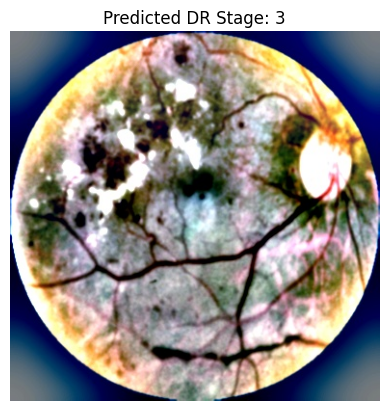

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

final_model, final_thresholds = load_final_model(device)

sample_image = val_df.iloc[2]["image_path"]

pred = predict_image(sample_image, final_model, final_thresholds, device)

print("Predicted DR Stage:", pred)

img = cv2.imread(sample_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Predicted DR Stage: {pred}")
plt.axis("off")
plt.show()
